# Manual Generation of Dynamic Obstacle Trajectories

In this notebook, we demonstrate how to manually populate a given map with dynamic obstacles by constructing their trajectories. 
Obstacle trajectories are assembled using motion primitives (in the exact same manner as the ego-robot's trajectories). 
However, different primitive sets can be utilized for different obstacles and the ego-robot. 

The resulting obstacles are saved into a `.txt` file, allowing you to manually fine-tune parameters such as the safety radius, insert wait/idle durations, etc., if necessary.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import time

# Append the common directory to the system path for module resolution
sys.path.append(os.path.abspath('../common'))
from manual_builder import TrajectoryBuilder
from DO_structs import *
from DO_graphics import *
from DO_searching import Map

%matplotlib inline

In [2]:
# 1. Load the Control Set
cs = ControlSet()
cs.load_primitives("../data/control_set.txt")

# 2. Load the map grid where obstacle trajectories will be drafted
task_map = Map()
task_map.read_from_movingai_file("../maps/arena.map")

In [10]:
# Select the initial state (spawn point) for the obstacle
start_obstacle_state = DiscreteState(i=42, j=25, theta=-6)

# Initialize the Trajectory Builder UI
# NOTE: The keys 'P' * correspond to specific motion primitives. 
# They are mapped from left to right in the exact order as the primitives 
# inside the bundle (ordered left-to-right by their final target state).
builder = TrajectoryBuilder(cs, task_map, start_obstacle_state, prefix_to_save="../dynamic_obstacles/arena_manual/")
builder.display()

# Trajectory Visualization and Animation Export

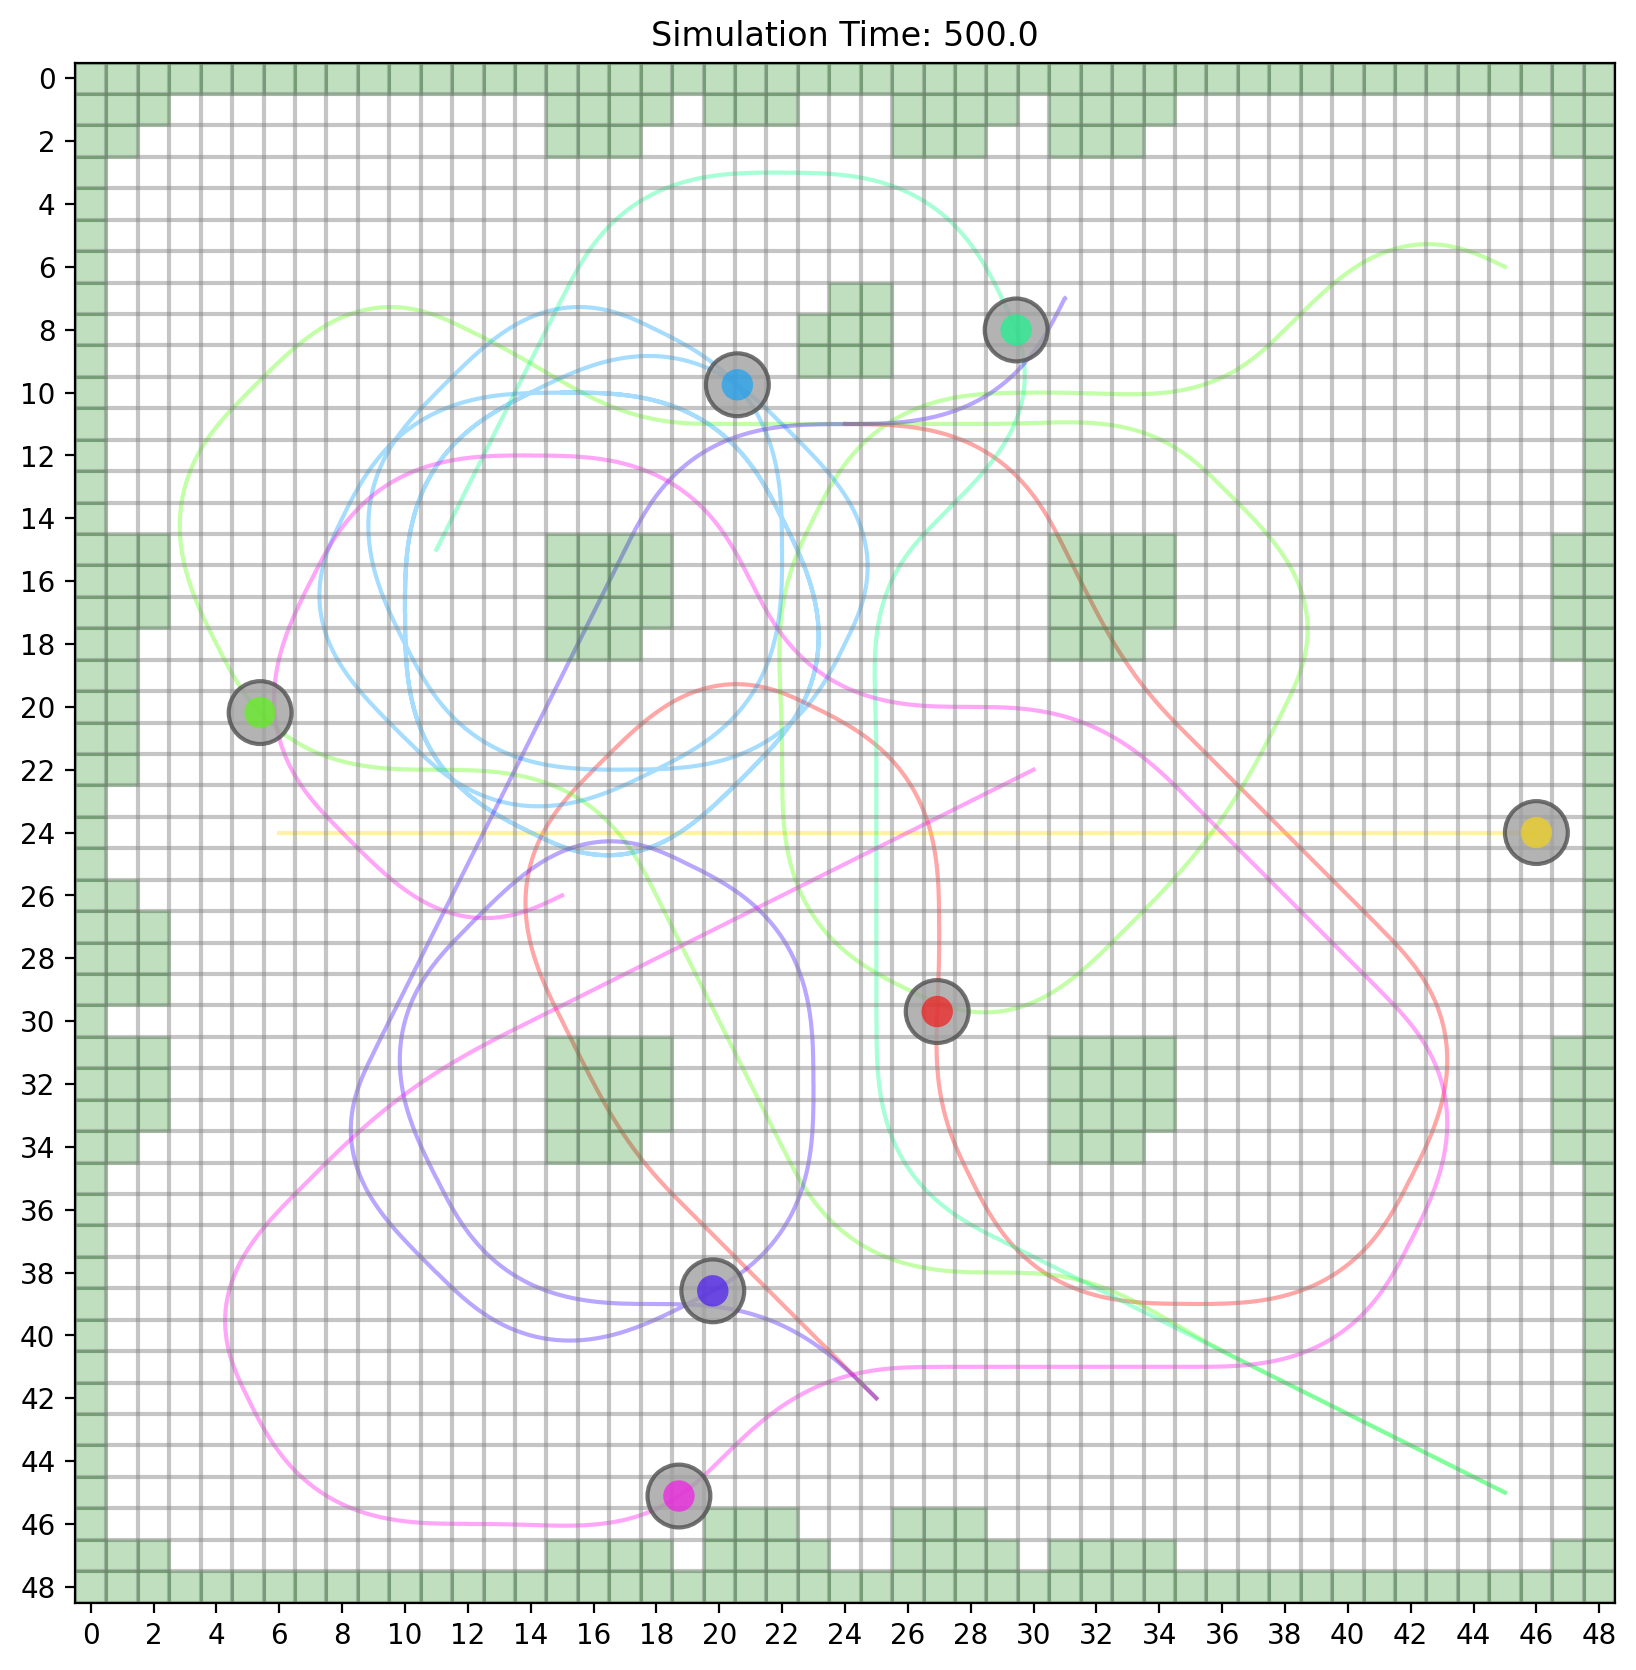

Saving GIF... Total frames compiled: 261
Simulation successfully saved to: ../media/arena_manual_demo.gif


In [11]:
# 1. Initialization
# Load all manually created dynamic obstacle trajectories from the directory
obs_set = ObstacleSet().load_dynamic_obstacles("../dynamic_obstacles/arena_manual/dynamic_obstacle_*.txt", cs)

# 2. Instantiate the Visualizer Environment
update_sim, save_sim = create_dynamic_visualizer(
    task_map=task_map,
    obstacle_set=obs_set,
    show_path=True,
    fast_draw=False,
    make_gif=True
)

# 3. Temporal Simulation Parameters
max_time = 500.0  # Total duration of the simulation in ticks
dt = 2            # Time step delta (controls animation speed and smoothness)
current_time = 0.0

# 4. Main Simulation Loop
while current_time <= max_time:
    update_sim(current_time)
    current_time += dt
    time.sleep(0.005)  # Micro-pause to allow the browser thread to render the frame smoothly

# 5. Export and Save Results
save_sim("../media/arena_manual_demo.gif", fps=20)